In [1]:
# %pip install langchain_mistralai deepagents firecrawl-py rich

In [2]:
import getpass
import json
import os
from datetime import datetime

from firecrawl import Firecrawl
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool
from deepagents import create_deep_agent
from rich.console import Console
from rich.markdown import Markdown

console = Console()

In [3]:
def get_today_str() -> str:
    """Return current date as a human-readable string."""
    return datetime.now().strftime("%a %b %-d, %Y")

def get_today_str() -> str:
    """Return current date as a human-readable string."""
    return datetime.now().strftime("%a %b %d, %Y").replace(" 0", " ")

get_today_str()

'Thu Apr 16, 2026'

# API keys

In [4]:
for key in ("MISTRAL_API_KEY", "FIRECRAWL_API_KEY"):
    if key not in os.environ:
        os.environ[key] = getpass.getpass(f"Enter {key}: ")

## Tools

In [5]:
firecrawl_client = Firecrawl(api_key=os.getenv("FIRECRAWL_API_KEY"))

@tool
def web_search(query: str, limit: int = 5) -> list[dict]:
    """Search the web for up-to-date information.

    Args:
        query: The search query string.
        limit: How many results to return (default 5).

    Returns:
        A list of result dicts, each with 'url', 'title', and 'markdown' keys.
    """
    results = firecrawl_client.search(query, limit=limit)
    # Normalise: always return a list of dicts
    if isinstance(results, dict):
        return results.get("data", []) or results.get("results", [])
    return results or []


@tool
def web_scrape(url: str) -> str:
    """Scrape the full content of a web page as Markdown.

    Use this after web_search to read the full text of a specific source.

    Args:
        url: The URL to scrape.

    Returns:
        Page content as a Markdown string.
    """
    try:
        result = firecrawl_client.scrape(url, formats=["markdown"])
        if isinstance(result, dict):
            return result.get("markdown") or result.get("data", {}).get("markdown") or ""
        return str(result)
    except Exception as e:
        # Some sites are not supported by Firecrawl; treat that as a non-fatal scrape failure.
        if e.__class__.__name__ == "WebsiteNotSupportedError":
            return ""
        return ""


@tool(parse_docstring=True)
def think_tool(reflection: str) -> str:
    """Record a strategic reflection to guide research decisions.

    Call this after each search round to:
    - Summarise what you've found so far
    - Identify gaps still to fill
    - Decide whether to keep searching or write the final report

    Args:
        reflection: Your detailed reasoning about current findings and next steps.

    Returns:
        Confirmation that the reflection was recorded.
    """
    return f"Reflection recorded: {reflection}"

## Sample Event

In [6]:
true = True
false = False
null = None

In [7]:
dummy_event = {
  "id": "357807",
  "ticker": "us-x-iran-permanent-peace-deal-by",
  "slug": "us-x-iran-permanent-peace-deal-by",
  "title": "US x Iran permanent peace deal by...?",
  "description": "This market will resolve to “Yes” if Iran and the United states agree to a permanent peace deal by the specified date, 11:59 PM ET. Otherwise, this market will resolve to “No”. \n\nA permanent peace deal refers to any agreement which explicitly indicates that military hostilities between the United States and Iran have ended or will permanently cease, or uses equivalent language clearly signaling a lasting end to military hostilities between the United States and Iran. Agreements that are explicitly temporary or which do not include a definitive agreement to end military hostilities between the US and Iran on a lasting basis (e.g. a temporary extension of the two-week ceasefire agreement announced on April 7, 2026), will not qualify.\n\nA qualifying agreement will be considered to have been established if either of the following conditions are met:\n\n- The United States and Iran each sign or formally adopt a written agreement (e.g. a treaty or multi-point agreement) which meets the above criteria.\n\n- Both the governments of the United States and Iran provide clear public confirmation that a qualifying agreement has been definitively established. Negotiations, statements of progress, or other statements which do not constitute a definitive announcement that a qualifying agreement has been reached will not count.\n\nThe primary resolution source for this market will be official information from the governments of the United States and Iran; however, a consensus of credible reporting may also be used.",
  "resolutionSource": "",
  "startDate": "2026-04-08T16:23:18.231513Z",
  "creationDate": "2026-04-08T16:23:18.231506Z",
  "endDate": "2026-05-31T00:00:00Z",
  "image": "https://polymarket-upload.s3.us-east-2.amazonaws.com/us-x-iran-permanent-peace-deal-by-yYlzv70Hi7j9.jpg",
  "icon": "https://polymarket-upload.s3.us-east-2.amazonaws.com/us-x-iran-permanent-peace-deal-by-yYlzv70Hi7j9.jpg",
  "active": true,
  "closed": false,
  "archived": false,
  "new": false,
  "featured": true,
  "restricted": true,
  "liquidity": 422701.34,
  "volume": 5230839.775712969,
  "openInterest": 2032569.586577,
  "createdAt": "2026-04-08T16:01:09.010584Z",
  "updatedAt": "2026-04-15T03:09:18.046893Z",
  "competitive": 0.9993753903810119,
  "volume24hr": 1740034.563308,
  "volume1wk": 5230839.775712992,
  "volume1mo": 5230839.775712992,
  "volume1yr": 5230839.775712992,
  "enableOrderBook": true,
  "liquidityClob": 422701.34,
  "negRisk": false,
  "commentCount": 119,
  "markets": [
    {
      "id": "1919417",
      "question": "US x Iran permanent peace deal by April 22, 2026?",
      "conditionId": "0xbbc6689d0f6d57ea42168836712237c7308b3e0118c8914d31b6126d0f3254c5",
      "slug": "us-x-iran-permanent-peace-deal-by-april-22-2026",
      "resolutionSource": "",
      "endDate": "2026-04-22T00:00:00Z",
      "liquidity": "190360.9385",
      "startDate": "2026-04-08T16:16:14.414324Z",
      "image": "https://polymarket-upload.s3.us-east-2.amazonaws.com/us-x-iran-permanent-peace-deal-by-yYlzv70Hi7j9.jpg",
      "icon": "https://polymarket-upload.s3.us-east-2.amazonaws.com/us-x-iran-permanent-peace-deal-by-yYlzv70Hi7j9.jpg",
      "description": "This market will resolve to “Yes” if Iran and the United states agree to a permanent peace deal by the specified date, 11:59 PM ET. Otherwise, this market will resolve to “No”. \n\nA permanent peace deal refers to any agreement which explicitly indicates that military hostilities between the United States and Iran have ended or will permanently cease, or uses equivalent language clearly signaling a lasting end to military hostilities between the United States and Iran. Agreements that are explicitly temporary or which do not include a definitive agreement to end military hostilities between the US and Iran on a lasting basis (e.g. a temporary extension of the two-week ceasefire agreement announced on April 7, 2026), will not qualify.\n\nA qualifying agreement will be considered to have been established if either of the following conditions are met:\n\n- The United States and Iran each sign or formally adopt a written agreement (e.g. a treaty or multi-point agreement) which meets the above criteria.\n\n- Both the governments of the United States and Iran provide clear public confirmation that a qualifying agreement has been definitively established. Negotiations, statements of progress, or other statements which do not constitute a definitive announcement that a qualifying agreement has been reached will not count.\n\nThe primary resolution source for this market will be official information from the governments of the United States and Iran; however, a consensus of credible reporting may also be used.",
      "outcomes": "[\"Yes\", \"No\"]",
      "outcomePrices": "[\"0.235\", \"0.765\"]",
      "volume": "3430877.2986319717",
      "active": true,
      "closed": false,
      "marketMakerAddress": "",
      "createdAt": "2026-04-08T16:01:11.063822Z",
      "updatedAt": "2026-04-15T03:06:03.328654Z",
      "new": false,
      "featured": false,
      "submitted_by": "0x91430CaD2d3975766499717fA0D66A78D814E5c5",
      "archived": false,
      "resolvedBy": "0x65070BE91477460D8A7AeEb94ef92fe056C2f2A7",
      "restricted": true,
      "groupItemTitle": "April 22",
      "groupItemThreshold": "0",
      "questionID": "0xc1803b659426dddde273d5c6198f5b3835b53d4301e533e0590b42f5a11a00f7",
      "enableOrderBook": true,
      "orderPriceMinTickSize": 0.01,
      "orderMinSize": 5,
      "volumeNum": 3430877.2986319717,
      "liquidityNum": 190360.9385,
      "endDateIso": "2026-04-22",
      "startDateIso": "2026-04-08",
      "hasReviewedDates": true,
      "volume24hr": 1071839.819711,
      "volume1wk": 3430877.2986319917,
      "volume1mo": 3430877.2986319917,
      "volume1yr": 3430877.2986319917,
      "clobTokenIds": "[\"10355316169421062771540371697837923442956106006258739802114788264214901200573\", \"112998834930140849739317686306046962022222428099467375077336504369963794934957\"]",
      "umaBond": "500",
      "umaReward": "5",
      "volume24hrClob": 1071839.819711,
      "volume1wkClob": 3430877.2986319917,
      "volume1moClob": 3430877.2986319917,
      "volume1yrClob": 3430877.2986319917,
      "volumeClob": 3430877.2986319717,
      "liquidityClob": 190360.9385,
      "customLiveness": 0,
      "acceptingOrders": true,
      "negRisk": false,
      "negRiskRequestID": "",
      "ready": false,
      "funded": false,
      "acceptingOrdersTimestamp": "2026-04-08T16:15:09Z",
      "cyom": false,
      "competitive": 0.934382956854867,
      "pagerDutyNotificationEnabled": false,
      "approved": true,
      "clobRewards": [
        {
          "id": "143364",
          "conditionId": "0xbbc6689d0f6d57ea42168836712237c7308b3e0118c8914d31b6126d0f3254c5",
          "assetAddress": "0x2791Bca1f2de4661ED88A30C99A7a9449Aa84174",
          "rewardsAmount": 0,
          "rewardsDailyRate": 1000,
          "startDate": "2026-04-08",
          "endDate": "2500-12-31"
        }
      ],
      "rewardsMinSize": 200,
      "rewardsMaxSpread": 4.5,
      "spread": 0.01,
      "oneDayPriceChange": 0.13,
      "oneHourPriceChange": 0.01,
      "lastTradePrice": 0.23,
      "bestBid": 0.23,
      "bestAsk": 0.24,
      "automaticallyActive": true,
      "clearBookOnStart": true,
      "seriesColor": "",
      "showGmpSeries": false,
      "showGmpOutcome": false,
      "manualActivation": false,
      "negRiskOther": false,
      "umaResolutionStatuses": "[]",
      "pendingDeployment": false,
      "deploying": false,
      "deployingTimestamp": "2026-04-08T16:11:34.342398Z",
      "rfqEnabled": false,
      "holdingRewardsEnabled": false,
      "feesEnabled": false,
      "requiresTranslation": false,
      "feeType": null
    },
    {
      "id": "1919421",
      "question": "US x Iran permanent peace deal by April 30, 2026?",
      "conditionId": "0xceb6dfaa2cf5abc9d47ebc867b984a7715104944249274e8a483a2e17473e5f5",
      "slug": "us-x-iran-permanent-peace-deal-by-april-30-2026",
      "resolutionSource": "",
      "endDate": "2026-04-30T00:00:00Z",
      "liquidity": "76499.4187",
      "startDate": "2026-04-08T16:16:30.033131Z",
      "image": "https://polymarket-upload.s3.us-east-2.amazonaws.com/us-x-iran-permanent-peace-deal-by-yYlzv70Hi7j9.jpg",
      "icon": "https://polymarket-upload.s3.us-east-2.amazonaws.com/us-x-iran-permanent-peace-deal-by-yYlzv70Hi7j9.jpg",
      "description": "This market will resolve to “Yes” if Iran and the United states agree to a permanent peace deal by the specified date, 11:59 PM ET. Otherwise, this market will resolve to “No”. \n\nA permanent peace deal refers to any agreement which explicitly indicates that military hostilities between the United States and Iran have ended or will permanently cease, or uses equivalent language clearly signaling a lasting end to military hostilities between the United States and Iran. Agreements that are explicitly temporary or which do not include a definitive agreement to end military hostilities between the US and Iran on a lasting basis (e.g. a temporary extension of the two-week ceasefire agreement announced on April 7, 2026), will not qualify.\n\nA qualifying agreement will be considered to have been established if either of the following conditions are met:\n\n- The United States and Iran each sign or formally adopt a written agreement (e.g. a treaty or multi-point agreement) which meets the above criteria.\n\n- Both the governments of the United States and Iran provide clear public confirmation that a qualifying agreement has been definitively established. Negotiations, statements of progress, or other statements which do not constitute a definitive announcement that a qualifying agreement has been reached will not count.\n\nThe primary resolution source for this market will be official information from the governments of the United States and Iran; however, a consensus of credible reporting may also be used.",
      "outcomes": "[\"Yes\", \"No\"]",
      "outcomePrices": "[\"0.335\", \"0.665\"]",
      "volume": "956262.7663369961",
      "active": true,
      "closed": false,
      "marketMakerAddress": "",
      "createdAt": "2026-04-08T16:01:11.581938Z",
      "updatedAt": "2026-04-15T03:05:27.850063Z",
      "new": false,
      "featured": false,
      "submitted_by": "0x91430CaD2d3975766499717fA0D66A78D814E5c5",
      "archived": false,
      "resolvedBy": "0x65070BE91477460D8A7AeEb94ef92fe056C2f2A7",
      "restricted": true,
      "groupItemTitle": "April 30",
      "groupItemThreshold": "1",
      "questionID": "0xc632d4b9a33b093c15a28a23401e16c438c25debe936c9bc89ea045079893460",
      "enableOrderBook": true,
      "orderPriceMinTickSize": 0.01,
      "orderMinSize": 5,
      "volumeNum": 956262.7663369961,
      "liquidityNum": 76499.4187,
      "endDateIso": "2026-04-30",
      "startDateIso": "2026-04-08",
      "hasReviewedDates": true,
      "volume24hr": 331145.32389100036,
      "volume1wk": 956262.7663370005,
      "volume1mo": 956262.7663370005,
      "volume1yr": 956262.7663370005,
      "clobTokenIds": "[\"64575112906857627673396031002364315784778510108272214779568803819416675082435\", \"16735391771285941445401615956052324743124272348274952820359859379638645997506\"]",
      "umaBond": "500",
      "umaReward": "5",
      "volume24hrClob": 331145.32389100036,
      "volume1wkClob": 956262.7663370005,
      "volume1moClob": 956262.7663370005,
      "volume1yrClob": 956262.7663370005,
      "volumeClob": 956262.7663369961,
      "liquidityClob": 76499.4187,
      "customLiveness": 0,
      "acceptingOrders": true,
      "negRisk": false,
      "negRiskRequestID": "",
      "ready": false,
      "funded": false,
      "acceptingOrdersTimestamp": "2026-04-08T16:15:25Z",
      "cyom": false,
      "competitive": 0.9734965562559322,
      "pagerDutyNotificationEnabled": false,
      "approved": true,
      "clobRewards": [
        {
          "id": "143363",
          "conditionId": "0xceb6dfaa2cf5abc9d47ebc867b984a7715104944249274e8a483a2e17473e5f5",
          "assetAddress": "0x2791Bca1f2de4661ED88A30C99A7a9449Aa84174",
          "rewardsAmount": 0,
          "rewardsDailyRate": 500,
          "startDate": "2026-04-08",
          "endDate": "2500-12-31"
        }
      ],
      "rewardsMinSize": 200,
      "rewardsMaxSpread": 4.5,
      "spread": 0.01,
      "oneDayPriceChange": 0.11,
      "oneHourPriceChange": 0.01,
      "lastTradePrice": 0.34,
      "bestBid": 0.33,
      "bestAsk": 0.34,
      "automaticallyActive": true,
      "clearBookOnStart": true,
      "seriesColor": "",
      "showGmpSeries": false,
      "showGmpOutcome": false,
      "manualActivation": false,
      "negRiskOther": false,
      "umaResolutionStatuses": "[]",
      "pendingDeployment": false,
      "deploying": false,
      "deployingTimestamp": "2026-04-08T16:11:34.343558Z",
      "rfqEnabled": false,
      "holdingRewardsEnabled": false,
      "feesEnabled": false,
      "requiresTranslation": false,
      "feeType": null
    },
    {
      "id": "1919425",
      "question": "US x Iran permanent peace deal by May 31, 2026?",
      "conditionId": "0x0e4a0c937b8934c2475613b6322b3f8edc8dedc24762e01e42b0e6f87424a089",
      "slug": "us-x-iran-permanent-peace-deal-by-may-31-2026",
      "resolutionSource": "",
      "endDate": "2026-05-31T00:00:00Z",
      "liquidity": "91550.1844",
      "startDate": "2026-04-08T16:19:31.125126Z",
      "image": "https://polymarket-upload.s3.us-east-2.amazonaws.com/us-x-iran-permanent-peace-deal-by-yYlzv70Hi7j9.jpg",
      "icon": "https://polymarket-upload.s3.us-east-2.amazonaws.com/us-x-iran-permanent-peace-deal-by-yYlzv70Hi7j9.jpg",
      "description": "This market will resolve to “Yes” if Iran and the United states agree to a permanent peace deal by the specified date, 11:59 PM ET. Otherwise, this market will resolve to “No”. \n\nA permanent peace deal refers to any agreement which explicitly indicates that military hostilities between the United States and Iran have ended or will permanently cease, or uses equivalent language clearly signaling a lasting end to military hostilities between the United States and Iran. Agreements that are explicitly temporary or which do not include a definitive agreement to end military hostilities between the US and Iran on a lasting basis (e.g. a temporary extension of the two-week ceasefire agreement announced on April 7, 2026), will not qualify.\n\nA qualifying agreement will be considered to have been established if either of the following conditions are met:\n\n- The United States and Iran each sign or formally adopt a written agreement (e.g. a treaty or multi-point agreement) which meets the above criteria.\n\n- Both the governments of the United States and Iran provide clear public confirmation that a qualifying agreement has been definitively established. Negotiations, statements of progress, or other statements which do not constitute a definitive announcement that a qualifying agreement has been reached will not count.\n\nThe primary resolution source for this market will be official information from the governments of the United States and Iran; however, a consensus of credible reporting may also be used.",
      "outcomes": "[\"Yes\", \"No\"]",
      "outcomePrices": "[\"0.525\", \"0.475\"]",
      "volume": "689076.2705740008",
      "active": true,
      "closed": false,
      "marketMakerAddress": "",
      "createdAt": "2026-04-08T16:01:12.366805Z",
      "updatedAt": "2026-04-15T03:06:13.126023Z",
      "new": false,
      "featured": false,
      "submitted_by": "0x91430CaD2d3975766499717fA0D66A78D814E5c5",
      "archived": false,
      "resolvedBy": "0x65070BE91477460D8A7AeEb94ef92fe056C2f2A7",
      "restricted": true,
      "groupItemTitle": "May 31",
      "groupItemThreshold": "2",
      "questionID": "0xaebb7e7a586ea44a8d7ce41837f4ed734c07b12f69f853f80bf06266768aa750",
      "enableOrderBook": true,
      "orderPriceMinTickSize": 0.01,
      "orderMinSize": 5,
      "volumeNum": 689076.2705740008,
      "liquidityNum": 91550.1844,
      "endDateIso": "2026-05-31",
      "startDateIso": "2026-04-08",
      "hasReviewedDates": true,
      "volume24hr": 257452.54274600008,
      "volume1wk": 689076.2705739996,
      "volume1mo": 689076.2705739996,
      "volume1yr": 689076.2705739996,
      "clobTokenIds": "[\"72094069823942324362885404801938332659316240217382754851102758232469673300092\", \"42918220085288219341491829385501246298233444593663440094436147850542032590016\"]",
      "umaBond": "500",
      "umaReward": "5",
      "volume24hrClob": 257452.54274600008,
      "volume1wkClob": 689076.2705739996,
      "volume1moClob": 689076.2705739996,
      "volume1yrClob": 689076.2705739996,
      "volumeClob": 689076.2705740008,
      "liquidityClob": 91550.1844,
      "customLiveness": 0,
      "acceptingOrders": true,
      "negRisk": false,
      "negRiskRequestID": "",
      "ready": false,
      "funded": false,
      "acceptingOrdersTimestamp": "2026-04-08T16:18:27Z",
      "cyom": false,
      "competitive": 0.9993753903810119,
      "pagerDutyNotificationEnabled": false,
      "approved": true,
      "clobRewards": [
        {
          "id": "143362",
          "conditionId": "0x0e4a0c937b8934c2475613b6322b3f8edc8dedc24762e01e42b0e6f87424a089",
          "assetAddress": "0x2791Bca1f2de4661ED88A30C99A7a9449Aa84174",
          "rewardsAmount": 0,
          "rewardsDailyRate": 400,
          "startDate": "2026-04-08",
          "endDate": "2500-12-31"
        }
      ],
      "rewardsMinSize": 200,
      "rewardsMaxSpread": 4.5,
      "spread": 0.01,
      "oneDayPriceChange": 0.145,
      "oneHourPriceChange": -0.01,
      "lastTradePrice": 0.52,
      "bestBid": 0.52,
      "bestAsk": 0.53,
      "automaticallyActive": true,
      "clearBookOnStart": true,
      "seriesColor": "",
      "showGmpSeries": false,
      "showGmpOutcome": false,
      "manualActivation": false,
      "negRiskOther": false,
      "umaResolutionStatuses": "[]",
      "pendingDeployment": false,
      "deploying": false,
      "deployingTimestamp": "2026-04-08T16:11:34.344672Z",
      "rfqEnabled": false,
      "holdingRewardsEnabled": false,
      "feesEnabled": false,
      "requiresTranslation": false,
      "feeType": null
    },
    {
      "id": "1962237",
      "question": "US x Iran permanent peace deal by June 30, 2026?",
      "conditionId": "0x6114a8a3f9ac214f48a7e20d169f1c7a5c84082cb6f7058ed9fe1137b11fd0e7",
      "slug": "us-x-iran-permanent-peace-deal-by-june-30-2026",
      "resolutionSource": "",
      "endDate": "2026-05-31T00:00:00Z",
      "liquidity": "65821.8946",
      "startDate": "2026-04-12T20:50:20.876004Z",
      "image": "https://polymarket-upload.s3.us-east-2.amazonaws.com/us-x-iran-permanent-peace-deal-by-yYlzv70Hi7j9.jpg",
      "icon": "https://polymarket-upload.s3.us-east-2.amazonaws.com/us-x-iran-permanent-peace-deal-by-yYlzv70Hi7j9.jpg",
      "description": "This market will resolve to “Yes” if Iran and the United states agree to a permanent peace deal by the specified date, 11:59 PM ET. Otherwise, this market will resolve to “No”. \n\nA permanent peace deal refers to any agreement which explicitly indicates that military hostilities between the United States and Iran have ended or will permanently cease, or uses equivalent language clearly signaling a lasting end to military hostilities between the United States and Iran. Agreements that are explicitly temporary or which do not include a definitive agreement to end military hostilities between the US and Iran on a lasting basis (e.g. a temporary extension of the two-week ceasefire agreement announced on April 7, 2026), will not qualify.\n\nA qualifying agreement will be considered to have been established if either of the following conditions are met:\n\n- The United States and Iran each sign or formally adopt a written agreement (e.g. a treaty or multi-point agreement) which meets the above criteria.\n\n- Both the governments of the United States and Iran provide clear public confirmation that a qualifying agreement has been definitively established. Negotiations, statements of progress, or other statements which do not constitute a definitive announcement that a qualifying agreement has been reached will not count.\n\nThe primary resolution source for this market will be official information from the governments of the United States and Iran; however, a consensus of credible reporting may also be used.",
      "outcomes": "[\"Yes\", \"No\"]",
      "outcomePrices": "[\"0.68\", \"0.32\"]",
      "volume": "154836.698023",
      "active": true,
      "closed": false,
      "marketMakerAddress": "",
      "createdAt": "2026-04-12T20:47:43.363632Z",
      "updatedAt": "2026-04-15T03:05:49.99921Z",
      "new": false,
      "featured": false,
      "submitted_by": "0x91430CaD2d3975766499717fA0D66A78D814E5c5",
      "archived": false,
      "resolvedBy": "0x65070BE91477460D8A7AeEb94ef92fe056C2f2A7",
      "restricted": true,
      "groupItemTitle": "June 30",
      "groupItemThreshold": "3",
      "questionID": "0xf214eceb5c5761b24a5957a6bff8f01be990b84925eaf38303f98c506602702c",
      "enableOrderBook": true,
      "orderPriceMinTickSize": 0.01,
      "orderMinSize": 5,
      "volumeNum": 154836.698023,
      "liquidityNum": 65821.8946,
      "endDateIso": "2026-05-31",
      "startDateIso": "2026-04-12",
      "hasReviewedDates": true,
      "volume24hr": 79679.60990999997,
      "volume1wk": 154836.69802300006,
      "volume1mo": 154836.69802300006,
      "volume1yr": 154836.69802300006,
      "clobTokenIds": "[\"31867385211987925701696042012772036156561382644688734856312468506547392739862\", \"34730098823282204056880725250863591694415190633560416900548276632326632294207\"]",
      "umaBond": "500",
      "umaReward": "5",
      "volume24hrClob": 79679.60990999997,
      "volume1wkClob": 154836.69802300006,
      "volume1moClob": 154836.69802300006,
      "volume1yrClob": 154836.69802300006,
      "volumeClob": 154836.698023,
      "liquidityClob": 65821.8946,
      "customLiveness": 0,
      "acceptingOrders": true,
      "negRisk": false,
      "negRiskRequestID": "",
      "ready": false,
      "funded": false,
      "acceptingOrdersTimestamp": "2026-04-12T20:49:17Z",
      "cyom": false,
      "competitive": 0.9686168151879117,
      "pagerDutyNotificationEnabled": false,
      "approved": true,
      "clobRewards": [
        {
          "id": "177414",
          "conditionId": "0x6114a8a3f9ac214f48a7e20d169f1c7a5c84082cb6f7058ed9fe1137b11fd0e7",
          "assetAddress": "0x2791Bca1f2de4661ED88A30C99A7a9449Aa84174",
          "rewardsAmount": 0,
          "rewardsDailyRate": 10,
          "startDate": "2026-04-12",
          "endDate": "2500-12-31"
        }
      ],
      "rewardsMinSize": 50,
      "rewardsMaxSpread": 4.5,
      "spread": 0.02,
      "oneDayPriceChange": 0.205,
      "oneHourPriceChange": 0.005,
      "lastTradePrice": 0.69,
      "bestBid": 0.67,
      "bestAsk": 0.69,
      "automaticallyActive": true,
      "clearBookOnStart": true,
      "seriesColor": "",
      "manualActivation": false,
      "negRiskOther": false,
      "umaResolutionStatuses": "[]",
      "pendingDeployment": false,
      "deploying": false,
      "deployingTimestamp": "2026-04-12T20:48:05.723185Z",
      "rfqEnabled": false,
      "holdingRewardsEnabled": false,
      "feesEnabled": false,
      "requiresTranslation": false,
      "feeType": null
    }
  ],
  "tags": [
    {
      "id": "78",
      "label": "Iran",
      "slug": "iran",
      "forceShow": false,
      "publishedAt": "2023-11-02 21:16:51.647+00",
      "updatedBy": 15,
      "createdAt": "2023-11-02T21:16:51.667Z",
      "updatedAt": "2026-03-09T22:31:04.117508Z",
      "requiresTranslation": false
    },
    {
      "id": "126",
      "label": "Trump",
      "slug": "trump",
      "forceShow": false,
      "publishedAt": "2023-11-02 21:23:16.384+00",
      "updatedBy": 15,
      "createdAt": "2023-11-02T21:23:16.39Z",
      "updatedAt": "2026-03-09T22:19:01.330974Z",
      "requiresTranslation": false
    },
    {
      "id": "334",
      "label": "ceasefire",
      "slug": "ceasefire",
      "forceShow": false,
      "publishedAt": "2023-11-02 21:56:29.082+00",
      "updatedBy": 15,
      "createdAt": "2023-11-02T21:56:29.099Z",
      "updatedAt": "2026-03-09T22:33:38.503645Z",
      "requiresTranslation": false
    },
    {
      "id": "104010",
      "label": "Iran Ceasefire",
      "slug": "diplomacy-ceasefire",
      "forceShow": false,
      "createdAt": "2026-03-02T19:58:33.637952Z",
      "updatedAt": "2026-03-25T01:00:00.556226Z",
      "isCarousel": false,
      "requiresTranslation": false
    },
    {
      "id": "104513",
      "label": "Agreement",
      "slug": "agreement",
      "createdAt": "2026-04-08T16:01:12.865958Z",
      "updatedAt": "2026-04-08T16:05:58.921571Z",
      "requiresTranslation": false
    },
    {
      "id": "104514",
      "label": "10-point",
      "slug": "10-point",
      "createdAt": "2026-04-08T16:01:12.887189Z",
      "updatedAt": "2026-04-08T16:05:58.9205Z",
      "requiresTranslation": false
    },
    {
      "id": "104039",
      "label": "U.S. x Iran",
      "slug": "trump-iran",
      "forceShow": false,
      "createdAt": "2026-03-02T20:09:15.156731Z",
      "updatedAt": "2026-03-09T22:28:43.535987Z",
      "isCarousel": false,
      "requiresTranslation": false
    },
    {
      "id": "100265",
      "label": "Geopolitics",
      "slug": "geopolitics",
      "forceShow": true,
      "createdAt": "2024-06-12T20:13:03.615956Z",
      "updatedAt": "2026-03-09T22:29:03.520452Z",
      "requiresTranslation": false
    },
    {
      "id": "2",
      "label": "Politics",
      "slug": "politics",
      "forceShow": false,
      "publishedAt": "2023-10-25 18:55:50.674+00",
      "updatedBy": 13,
      "createdAt": "2023-10-25T18:55:50.681Z",
      "updatedAt": "2026-03-09T22:35:26.76623Z",
      "forceHide": true,
      "requiresTranslation": false
    }
  ],
  "cyom": false,
  "showAllOutcomes": true,
  "showMarketImages": false,
  "enableNegRisk": false,
  "automaticallyActive": true,
  "gmpChartMode": "default",
  "negRiskAugmented": false,
  "featuredOrder": 4,
  "estimateValue": false,
  "cumulativeMarkets": false,
  "pendingDeployment": false,
  "deploying": false,
  "requiresTranslation": false,
  "eventMetadata": {
    "context_description": "Recent collapse of direct US-Iran peace talks in Islamabad on April 12, after 21 hours of negotiations, has intensified tensions, prompting a US military blockade of Iranian ports and the Strait of Hormuz while a fragile ceasefire holds. US demands for zero uranium enrichment, missile program curbs, proxy funding halts, and nuclear site dismantling clashed with Iran's insistence on enrichment rights and Hormuz control, as outlined in its 10-point counterproposal. Despite the impasse, back-channel diplomacy signals potential second-round talks this week, possibly led by Vice President JD Vance in Pakistan, amid mutual war fatigue following February airstrikes. Traders assess slim odds for a permanent peace deal by June 30, hinging on breakthroughs in nuclear suspension, sanctions relief, and regional proxy de-escalation before escalation resumes.",
    "context_requires_regen": true,
    "context_updated_at": "2026-04-15T02:46:55.095Z"
  }
}


In [8]:
def format_event_context(event: dict) -> str:
    """Extract a compact, agent-readable summary from a raw Polymarket event dict."""
    markets = event.get("markets", [])

    market_lines = []
    for m in markets:
        outcomes = json.loads(m.get("outcomes", "[]"))
        prices   = json.loads(m.get("outcomePrices", "[]"))
        pairs    = ", ".join(f"{o}: {float(p):.0%}" for o, p in zip(outcomes, prices))
        market_lines.append(
            f"  - [{m['groupItemTitle']}] {m['question']}\n"
            f"    Prices: {pairs} | Vol: ${float(m['volumeNum']):,.0f} | "
            f"End: {m['endDateIso']}"
        )

    meta = event.get("eventMetadata", {}).get("context_description", "")

    return f"""
EVENT: {event['title']}
ID: {event['id']} | Tags: {', '.join(t['label'] for t in event.get('tags', []))}
Description: {event['description'][:600].strip()}...

MARKETS (outcome → current implied probability):
{chr(10).join(market_lines)}

TOTAL LIQUIDITY: ${event['liquidity']:,.0f} | TOTAL VOLUME: ${event['volume']:,.0f}
RESOLUTION: {event.get('endDate', 'N/A')}

CONTEXT (as of {event.get('eventMetadata', {}).get('context_updated_at', 'unknown')}):
{meta}
""".strip()

In [9]:
print(format_event_context(dummy_event))

EVENT: US x Iran permanent peace deal by...?
ID: 357807 | Tags: Iran, Trump, ceasefire, Iran Ceasefire, Agreement, 10-point, U.S. x Iran, Geopolitics, Politics
Description: This market will resolve to “Yes” if Iran and the United states agree to a permanent peace deal by the specified date, 11:59 PM ET. Otherwise, this market will resolve to “No”. 

A permanent peace deal refers to any agreement which explicitly indicates that military hostilities between the United States and Iran have ended or will permanently cease, or uses equivalent language clearly signaling a lasting end to military hostilities between the United States and Iran. Agreements that are explicitly temporary or which do not include a definitive agreement to end military hostilities between the...

MARKETS (outcome → current implied probability):
  - [April 22] US x Iran permanent peace deal by April 22, 2026?
    Prices: Yes: 24%, No: 76% | Vol: $3,430,877 | End: 2026-04-22
  - [April 30] US x Iran permanent peace de

## Agents

In [ ]:
from utils import show_prompt

# Limits
max_concurrent_research_units = 3
max_researcher_iterations = 3

In [11]:
RESEARCHER_SYSTEM_PROMPT = f"""You are a specialist research agent. Today is {get_today_str()}.

Your only job is to answer ONE specific research question thoroughly and return a structured finding.

## How to work
1. Run 2–4 targeted searches using `web_search`.
2. Scrape the 1–2 most relevant sources with `web_scrape` for full context.
3. Use `think` to assess whether you have enough evidence or need more searches.
4. Return a concise but complete answer with source URLs.

## Output format
Answer the question directly, then list:
- Key evidence (bullet points)
- Confidence: High / Medium / Low
- Sources (URLs)

Do NOT pad your answer. Stop searching once you have sufficient evidence."""

show_prompt(RESEARCHER_SYSTEM_PROMPT)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  You are a specialist research agent. Today is Thu Apr 16, 2026.                                                │
│                                                                                                                 │
│  Your only job is to answer ONE specific research question thoroughly and return a structured finding.          │
│                                                                                                                 │
│  ## How to work                                                                                                 │
│  1. Run 2–4 targeted searches using `web_search`.                                                               │
│  2. Scrape the 1–2 most relevant sources with `web_scrape` for full context.                                    │
│  3. Use `think` to assess whether you have enough evidence or need more searches.                               │
│  4. Return a concise but complete answer with source URLs.                                                      │
│                                                                                                                 │
│  ## Output format                                                                                               │
│  Answer the question directly, then list:                                                                       │
│  - Key evidence (bullet points)                                                                                 │
│  - Confidence: High / Medium / Low                                                                              │
│  - Sources (URLs)                                                                                               │
│                                                                                                                 │
│  Do NOT pad your answer. Stop searching once you have sufficient evidence.                                      │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [ ]:
SUPERVISOR_SYSTEM_PROMPT = f"""You are an expert Polymarket prediction-market research analyst. Today is {get_today_str()}.

You will receive a structured event summary that may contain MULTIPLE RELATED MARKETS for the same event.
Your job is to:
1. Determine whether the event is researchable at all.
2. If it is researchable, investigate the event deeply.
3. Translate the event-level research into MARKET-LEVEL trading judgment for each listed market.
4. Identify which market(s), if any, appear most attractive to trade, and on which side.

Follow this exact workflow.

## Step 1 — Classify the event
Decide whether the event is SPECULATIVE or RESEARCHABLE.

Definitions:
- SPECULATIVE: mostly driven by randomness, crowd sentiment, narrative reflexivity, arbitrary thresholds, or information that public research cannot meaningfully improve (examples: meme prices, vague popularity contests, arbitrary numerical targets with no causal anchor).
- RESEARCHABLE: driven by real-world actors, policies, negotiations, elections, legal processes, company fundamentals, macro data, sports/team information, measurable timelines, or other public evidence.

At the very top of your response, output exactly one of the following lines, with no preamble and no code fences:
CLASSIFICATION: SPECULATIVE
CLASSIFICATION: RESEARCHABLE

If CLASSIFICATION: SPECULATIVE
On the next line output:
REASON: <brief explanation in 1-2 sentences>
Then STOP immediately.

If CLASSIFICATION: RESEARCHABLE
Proceed to the next step.

## Step 2 — Plan the research
Use `write_todos` to create a clear plan with 4-7 todos.

The todos must cover BOTH:
A. Event-level research
B. Market-level pricing assessment

Your research plan should usually include questions in these categories:
- Current status: What is happening now?
- Resolution mechanics: What exactly would count for this market to resolve YES vs NO?
- Historical base rates / precedents: How often have similar outcomes happened, and how quickly?
- Catalysts and timeline: What upcoming events could materially change the odds before each market deadline?
- Structural blockers / enablers: What makes the outcome harder or easier?
- Market mapping: Given the above, which specific listed markets seem overpriced or underpriced?

Rules for planning:
- Create between 4 and 7 todos only.
- Keep each todo specific and answerable.
- Do not create vague todos like “research more deeply”.
- At least one todo must explicitly compare multiple listed markets against one another.

## Step 3 — Delegate research to sub-agents
Use the `task` tool to dispatch ONE focused research question per sub-agent call.
Run up to {max_concurrent_research_units} sub-agents in parallel when questions are independent.
Keep the main agent context clean; let sub-agents do focused work and return structured findings.

Delegation rules:
- One sub-agent task = one concrete question.
- Do not bundle multiple unrelated questions into one task.
- Prefer event-level questions first, then market-comparison questions once core facts are known.
- If an important gap remains after the first round, you may launch follow-up sub-agent tasks, but stay disciplined and avoid redundant searches.

## Step 4 — Build the event-level thesis
After the sub-agents finish, form a clear event-level view before judging individual markets.

You must answer:
- What is the most likely real-world outcome?
- What evidence most strongly supports that view?
- What are the biggest uncertainties?
- What is the rough probability distribution across the main scenario set?

Be explicit about timing:
A market can be directionally plausible in the long run but still unlikely by an earlier deadline.
Always distinguish:
- eventual plausibility
- probability before each listed market's resolution date

## Step 5 — Convert the thesis into market judgments
Now evaluate EACH listed market individually.

For every market, estimate:
- Market question / deadline
- Current implied probability from the provided market prices
- Your qualitative fair view: much lower / somewhat lower / about fair / somewhat higher / much higher
- Preferred side: YES / NO / NO TRADE
- Why: 1-3 concise sentences focused on edge, timing, and resolution criteria

Important:
- Do not recommend a trade just because the event seems likely overall.
- A market is attractive only if the listed price appears meaningfully misaligned with your researched view.
- Earlier-dated markets and later-dated markets should often receive different judgments.
- If the evidence is too weak or the price seems fair, say NO TRADE.

## Step 6 — Recommend the best opportunities
After evaluating all markets, identify the 0-3 most attractive opportunities across the event.

Selection criteria:
- strongest informational edge
- clearest mismatch between market price and researched view
- cleanest resolution criteria
- best timing/catalyst setup
- lowest dependence on unknown hidden information

If no market has a clear edge, explicitly say:
BEST OPPORTUNITIES: NONE

## Step 7 — Final output format
For RESEARCHABLE events, produce the final answer using exactly this structure:

### Market Overview
Brief summary of the event, the listed markets, the current market-implied probabilities, and the resolution criteria that matter most.

### Key Drivers
The 3-5 most important factors affecting the outcome.

### Evidence & Analysis
Summarize the strongest evidence for the main thesis, the strongest counter-evidence, and the key uncertainties.

### Scenario Analysis
Provide Bull / Base / Bear scenarios with rough qualitative probabilities and explain what each would imply for timing.

### Per-Market Assessment
Evaluate every listed market in a compact table with these columns:
| Market | Implied Prob. | Analyst View | Preferred Side | Attractiveness | Rationale |

Allowed values:
- Analyst View: much lower / somewhat lower / about fair / somewhat higher / much higher
- Preferred Side: YES / NO / NO TRADE
- Attractiveness: High / Medium / Low / None

### Best Opportunities
List up to 3 specific trade ideas.
For each one include:
- Market
- Side
- Why this market is more attractive than the others
- What would most likely invalidate the thesis

If none are attractive, say so explicitly.

### Catalysts & Timeline
List the upcoming events, announcements, deadlines, or data releases most likely to move the market.

### Risks & Unknowns
State what cannot be known from public information and what hidden variables could dominate the outcome.

### Verdict
Give a direct trader-usable conclusion:
- whether the event is broadly leaning YES or NO over time
- which specific markets look most mispriced
- which side, if any, looks best to trade
- whether the best action is selective exposure or no trade

Writing rules:
- Be direct and decision-useful.
- Separate event truth from market pricing.
- Do not hedge excessively.
- Do not recommend every market.
- It is acceptable to conclude that the event is researchable but none of the markets offer a clear edge.
"""

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  You are an expert Polymarket prediction-market research analyst. Today is Thu Apr 16, 2026.                    │
│                                                                                                                 │
│  You will receive a structured event summary. Follow this exact workflow:                                       │
│                                                                                                                 │
│  ## Step 1 — Classify the event                                                                                 │
│  Decide: is this event SPECULATIVE or RESEARCHABLE?                                                             │
│  - SPECULATIVE: driven by random chance, pure sentiment, or no public evidence can shift the odds (e.g.         │
│  memecoin prices, arbitrary numerical thresholds).                                                              │
│  - RESEARCHABLE: driven by real-world actors, policies, negotiations, data, or fundamentals.                    │
│                                                                                                                 │
│  If SPECULATIVE → explain why briefly and STOP. Do not fabricate deep analysis.                                 │
│                                                                                                                 │
│  ## Step 2 — Plan research questions (RESEARCHABLE only)                                                        │
│  Use `write_todos` to decompose the event into 3–6 specific, answerable research questions.                     │
│  Think in terms of:                                                                                             │
│  - Current status of negotiations / actors / events                                                             │
│  - Historical base rates and precedents                                                                         │
│  - Key upcoming catalysts and timelines                                                                         │
│  - Structural blockers or enablers                                                                              │
│                                                                                                                 │
│  ## Step 3 — Delegate research to sub-agents                                                                    │
│  Use the `task` tool to dispatch ONE research question per sub-agent call.                                      │
│  Run up to 3 sub-agents in parallel where questions are independent.                                            │
│  Keep the main agent context clean — sub-agents write findings to files.                                        │
│                                                                                                                 │
│  ## Step 4 — Synthesise a trader-usable report                                                                  │
│  After all sub-agents complete, compile findings into this structure:                                           │
│                                                                                                                 │
│  ### Market Overview                                                                                            │
│  Brief summary of the event, current market-implied probabilities, and resolution criteria.                     │
│                                                                                                                 │
│  ### Key Drivers                                                                                                │
│  The 3–5 most important factors affecting the outcome.

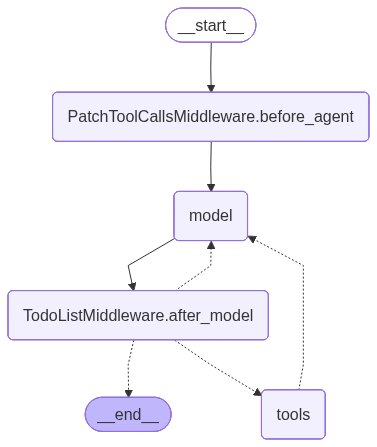

In [13]:
from IPython.display import Image, display
from deepagents import create_deep_agent
from langchain.chat_models import init_chat_model

if "MISTRAL_API_KEY" not in os.environ:
    os.environ["MISTRAL_API_KEY"] = getpass.getpass("Enter your Mistral API key: ")

research_subagent = {
    "name": "research-agent",
    "description": (
        "Delegate a single focused research question to this sub-agent. "
        "It will search the web, scrape sources, and return structured findings. "
        "Give it ONE question at a time."
    ),
    "system_prompt": RESEARCHER_SYSTEM_PROMPT,
    "tools": [web_search, web_scrape, think_tool],
}

model = init_chat_model(
    model="mistralai:mistral-small-2603",
    max_retries=10,
    timeout=120,
)

agent = create_deep_agent(
    model=model,
    tools=[web_search, web_scrape, think_tool],
    subagents=[research_subagent],
    system_prompt=SUPERVISOR_SYSTEM_PROMPT,
)
    
# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

## Invoking

In [14]:
def stream_agent(event_dict: dict) -> str:
    """Stream the agent on a Polymarket event dict; print progress, return final text."""
    def _coerce_text(value) -> str:
        """Best-effort conversion of streamed tool/message content to markdown text."""
        if value is None:
            return ""
        if isinstance(value, str):
            return value
        if isinstance(value, list):
            parts: list[str] = []
            for p in value:
                if isinstance(p, str):
                    parts.append(p)
                elif hasattr(p, "text"):
                    parts.append(str(getattr(p, "text")))
                elif hasattr(p, "content"):
                    parts.append(str(getattr(p, "content")))
                else:
                    parts.append(str(p))
            return "".join(parts)
        return str(value)

    event_context = format_event_context(event_dict)
    user_message = f"Please research the following Polymarket event:\n\n{event_context}"

    console.rule("[bold cyan]Starting Polymarket Research Agent")
    console.print(f"[dim]{user_message[:300]}...[/dim]\n")

    import re

    final_chunks: list[str] = []
    classification = None  # either "SPECULATIVE" or "RESEARCHABLE"
    pending_ai_text = ""

    for chunk in agent.stream(
        {"messages": [{"role": "user", "content": user_message}]},
        stream_mode="messages",
    ):
        # chunk is (message, metadata) tuple
        message = chunk[0] if isinstance(chunk, tuple) else chunk
        if not message or not hasattr(message, "type"):
            continue

        if message.type == "ai":
            # Text tokens
            text = _coerce_text(getattr(message, "content", ""))
            if text:
                console.print(text, end="", highlight=False)

                # Supervisor must start with a `CLASSIFICATION:` header line.
                if classification is None:
                    pending_ai_text += text

                    if "\n" in pending_ai_text:
                        first_line = pending_ai_text.splitlines()[0]
                        match = re.match(r"\s*CLASSIFICATION:\s*(SPECULATIVE|RESEARCHABLE)\s*$", first_line)
                        if match:
                            classification = match.group(1)
                            lines = pending_ai_text.splitlines()

                            if classification == "SPECULATIVE":
                                # With the prompt, REASON is on the next line.
                                if len(lines) >= 2 and lines[1].strip():
                                    return "\n".join(lines[1:]).strip()
                                # Wait for the next line containing `REASON:`.
                            else:
                                # RESEARCHABLE: drop the classification header from the returned report.
                                remaining = "\n".join(lines[1:])
                                if remaining.strip():
                                    final_chunks.append(remaining)
                                pending_ai_text = ""
                else:
                    if classification == "SPECULATIVE":
                        pending_ai_text += text
                        if "\n" in pending_ai_text:
                            lines = pending_ai_text.splitlines()
                            if len(lines) >= 2 and lines[1].strip():
                                return "\n".join(lines[1:]).strip()
                    else:
                        final_chunks.append(text)
            # Tool call announcements
            if hasattr(message, "tool_calls"):
                for tc in (message.tool_calls or []):
                    name = tc.get("name", "?")
                    args = tc.get("args", {})
                    # Show just the first arg value as a preview
                    preview = next(iter(args.values()), "") if args else ""
                    console.print(f"\n[bold yellow]⚙ {name}[/bold yellow] [dim]{str(preview)[:120]}[/dim]")

        elif message.type == "tool":
            # Tool result summary
            name = getattr(message, "name", "tool")
            content_text = _coerce_text(getattr(message, "content", ""))
            preview = content_text[:200].replace("\n", " ")
            console.print(f"[green]✓ {name}[/green] [dim]{preview}[/dim]\n")
            # The supervisor's final write-out is typically produced by the `task` tool.
            if str(name) == "task" and content_text:
                final_chunks.append(content_text)

    console.rule("[bold cyan]Research Complete")
    return "".join(final_chunks).strip()

In [15]:
report = stream_agent(dummy_event)

─────────────────────────────────────── Starting Polymarket Research Agent ────────────────────────────────────────

Please research the following Polymarket event:

EVENT: US x Iran permanent peace deal by...?
ID: 357807 | Tags: Iran, Trump, ceasefire, Iran Ceasefire, Agreement, 10-point, U.S. x Iran, Geopolitics, Politics
Description: This market will resolve to “Yes” if Iran and the United states agree to a per...

✓ task ## **Current Status of US-Iran Negotiations (as of April 16, 2026)**  ### **Are second-round talks 
confirmed?** - **Second-round talks are not yet formally confirmed**, but there are strong indication

✓ task ## US Demands and Red Lines in Iran Negotiations (2025–2026)  ### **Core US Demands** The US has articulated
six explicit red lines in negotiations with Iran, as confirmed by senior US officials and m

✓ task Here is the research finding on Iran’s 10-point counterproposal and its negotiability with the US:  ---  ## 
Iran’s 10-Point Counterproposal: Exact Terms  **Iran’s 10-point proposal**—delivered as a ba

✓ task ## Upcoming US/Iran Catalysts and Timelines (Polymarket Deadlines)  ### **Answer** Below are the most 
significant catalysts and timelines for the Polymarket deadlines: **April 22, April 30, May 31, an

✓ task ## **Structural Blockers and Enablers for a US-Iran Permanent Peace Deal**  ### **Direct Answer**  A US-Iran
permanent peace deal is currently **structurally blocked** by a combination of factors: the

✓ task ## Historical Base Rates for US-Iran Nuclear/Peace Agreements  ### **Success Rates by Era**  - **JCPOA 
(2015–2018):**   - **Success rate:** Near-universal expert consensus that the JCPOA would have **

──────────────────────────────────────────────── Research Complete ────────────────────────────────────────────────

In [16]:
console.print(Markdown(report))

Current Status of US-Iran Negotiations (as of April 16, 2026)                                                      

Are second-round talks confirmed?                                                                                  

 • Second-round talks are not yet formally confirmed, but there are strong indications they could resume within    
   days if diplomatic efforts succeed.                                                                             
 • US President Donald Trump stated on April 14 that talks could resume in Islamabad over the next two days, though
   no official date has been set.                                                                                  
 • Pakistani mediators are actively shuttling between Tehran and Washington, with a Pakistani military delegation  
   visiting Tehran on April 15 to carry a new message from the US and discuss a second round.                      
 • AP reported on April 15 that Washington and Tehran had given an "in principle agreement" to extend the ceasefire
   to allow for further diplomatic overtures, but a US official told Reuters that no formal agreement on a         
   ceasefire extension has been made                                                                               
   yet.com/world/asia-pacific/us-begins-iran-port-blockade-oil-prices-ease-hopes-dialogue-2026-04-14/,aljazeera.com
   /news/2026/4/15/us-iran-talks-whats-the-latest-on-mediation-efforts.                                            

-------------------------------------------------------------------------------------------------------------------

Key Negotiators and Their Stated Positions                                                                         

United States                                                                                                      

 • Lead Negotiator: US Vice President JD Vance                                                                     
    • Position: Vance stated that the US seeks a "grand bargain" with Iran but emphasized that mistrust between the
      two sides is deep and cannot be resolved overnight.                                                          
    • Key Demands:                                                                                                 
       • Nuclear Program: A 20-year suspension of all Iranian nuclear activity, including uranium enrichment, and  
         the removal of enriched nuclear material from Iran.                                                       
       • Strait of Hormuz: Free passage through the Strait of Hormuz, with no tolls or restrictions.               
       • Sanctions: Iran must comply with all US demands before any sanctions relief can be discussed.             
    • Recent Action: The US imposed a naval blockade on Iranian ports on April 14, further escalating              
      pressure.com/world/asia-pacific/us-begins-iran-port-blockade-oil-prices-ease-hopes-dialogue-2026-04-14/,aljaz
      eera.com/news/2026/4/15/us-iran-talks-whats-the-latest-on-mediation-efforts.                                 

Iran                                                                                                               

 • Lead Negotiator: Parliament Speaker Mohammad Bagher Ghalibaf                                                    
    • Position: Iran insists it is committed to a diplomatic solution but rejects US conditions as unacceptable.   
    • Key Demands:                                                                                                 
       • Nuclear Program: Iran insists its enrichment program is for civilian purposes only and is compliant with  
         the Non-Proliferation Treaty (NPT).                                                                       
       • Sanctions Relief: Immediate and unconditional lifting of all US sanctions, including the release of frozen
         assets.                                